# Rental Price Modelling

This notebook builds and improves rental price prediction models using the merged modelling-ready dataset. It focuses on the Week 8/9 modelling tasks: target transformation, feature selection, validation-based model tuning, random versus time-based splitting, influence diagnostics, final test evaluation, and feature interpretation.

In [75]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

PROJECT_ROOT = Path("..").resolve()
DATA_PATH = PROJECT_ROOT / "data" / "curated" / "master_modelling_table.parquet"
PLOTS_DIR = PROJECT_ROOT / "plots"
OUTPUT_DIR = PROJECT_ROOT / "data" / "curated"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## Load Data

The modelling table already combines the cleaned Domain rental listings, spatial accessibility features, and SA2-level external variables. Only modelling-ready rows are used for model training.

In [76]:
df = pd.read_parquet(DATA_PATH)

model_df = df.copy()
if "is_modelling_ready" in model_df.columns:
    model_df = model_df[model_df["is_modelling_ready"]].copy()

model_df = model_df[model_df["weekly_rent"].notna() & (model_df["weekly_rent"] > 0)].copy()
model_df["date_listed_dt"] = pd.to_datetime(model_df["date_listed"], errors="coerce")

print("Full dataset:", df.shape)
print("Modelling dataset:", model_df.shape)
print("Date listed range:", model_df["date_listed_dt"].min(), "to", model_df["date_listed_dt"].max())
model_df.head()

Full dataset: (11943, 83)
Modelling dataset: (11943, 84)
Date listed range: 2025-01-07 00:00:00 to 2025-09-09 00:00:00


,listing_id,suburb,postcode,lat,lon,weekly_rent,bond,available_date,date_listed,days_listed,bedrooms,bathrooms,carspaces,scraped_date,photo_count,video_count,floorplans_count,virtual_tour,property_type,primary_type,secondary_type,available_date_clean,available_weekday,bond_imputed,carspaces_imputed,sa2_code_2021,sa2_name_2021,in_victoria,straight_km_to_cbd,route_km_to_cbd,route_min_to_cbd,straight_km_to_nearest_station,est_route_km_to_nearest_station,nearest_station_name,n_stations_within_1km,n_stations_within_2km,straight_km_to_nearest_school,nearest_school_name,n_schools_within_1km,n_schools_within_2km,straight_km_to_nearest_park,straight_km_to_nearest_named_park,nearest_named_park,n_parks_within_500m,n_parks_within_1km,straight_km_to_nearest_mall,nearest_mall_name,sa3_name,sa4_name,gcc_name,area_sqkm,population_2021,population_2026,population_2031,population_2036,households_2026,households_2036,dwellings_2026,dwellings_2036,population_growth_5y,population_growth_10y,household_growth_10y,dwelling_growth_10y,demand_supply_gap_10y,occupancy_ratio_2026,avg_household_size_2026,is_residential,is_analysable,earners,median_age_earners,income_median,income_mean,income_growth_5y,income_skew_ratio,income_reliable,population_density_2026,is_modelling_ready,n_schools,n_primary_schools,n_secondary_schools,n_government_schools,n_stations,n_stations_both_networks,date_listed_dt
0,16782629,SOUTH KINGSVILLE,3015,-37.8310,144.8709,460.0000,"1,994.0000","Tuesday, 02 September 2025",2025-08-13,27.0000,2.0000,1.0000,2.0000,2025-09-09 06:18:52,10.0000,0.0000,0.0000,False,Apartment / Unit / Flat,Apartment,Apartment / Unit / Flat,2025-09-02,Tuesday,0,0,213021344,Newport,True,8.5850,11.0101,15.9835,1.3232,2.0335,Spotswood Railway Station,0,2,0.6365,St Margaret Mary's School,2,9,0.4028,0.4028,Edwards Reserve,1,8,2.0880,Altona Gate Shopping Centre,Hobsons Bay,Melbourne - West,Greater Melbourne,8.8407,"18,983.0000","20,333.0287","21,435.5001","22,363.0005","8,077.1000","9,100.6400","8,732.0000","9,892.0000",0.0542,0.0998,0.1267,0.1328,-0.0061,0.9250,2.5174,True,True,"13,008.0000",42.0000,"80,487.0000","96,888.0000",0.1819,1.2038,True,"2,299.9342",True,5,5,0,3,3,0,2025-08-13
1,17471867,SOUTH KINGSVILLE,3015,-37.8262,144.8675,400.0000,"1,738.0000","Thursday, 27 March 2025",2025-03-06,187.0000,2.0000,1.0000,1.0000,2025-09-09 06:18:52,11.0000,0.0000,0.0000,False,Apartment / Unit / Flat,Apartment,Apartment / Unit / Flat,2025-03-27,Thursday,0,0,213021344,Newport,True,8.8089,11.3516,16.3463,1.6912,2.5991,Spotswood Railway Station,0,1,0.8350,Wembley Primary School,2,8,0.1636,0.2618,Edwards Reserve,3,7,1.7730,Altona Gate Shopping Centre,Hobsons Bay,Melbourne - West,Greater Melbourne,8.8407,"18,983.0000","20,333.0287","21,435.5001","22,363.0005","8,077.1000","9,100.6400","8,732.0000","9,892.0000",0.0542,0.0998,0.1267,0.1328,-0.0061,0.9250,2.5174,True,True,"13,008.0000",42.0000,"80,487.0000","96,888.0000",0.1819,1.2038,True,"2,299.9342",True,5,5,0,3,3,0,2025-03-06
2,17721851,SOUTH KINGSVILLE,3015,-37.8312,144.8663,795.0000,"3,454.0000","Monday, 15 September 2025",2025-08-19,21.0000,3.0000,2.0000,3.0000,2025-09-09 06:18:52,12.0000,0.0000,1.0000,False,Townhouse,Townhouse/Villa,Townhouse,2025-09-15,Monday,0,0,213021343,Altona North,True,8.9881,11.4327,16.4788,1.7279,2.6555,Spotswood Railway Station,0,2,1.0324,St Margaret Mary's School,0,10,0.1260,0.5398,Edwards Reserve,2,8,1.6966,Altona Gate Shopping Centre,Hobsons Bay,Melbourne - West,Greater Melbourne,16.1844,"15,084.0000","16,660.3435","19,273.9200","21,877.9205","6,775.6250","9,094.2000","7,325.0000","9,885.0000",0.1569,0.3132,0.3422,0.3495,-0.0073,0.9250,2.4589,True,True,"9,267.0000",38.0000,"66,099.0000","81,630.0000",0.2071,1.2350,True,"1,029.4075",True,5,4,1,1,0,0,2025-08-19
3,17725855,SOUTH KINGSVILLE,3015,-37.8274,144.8677,675.0000,"2,933.0000","Wednesday, 20 August 2025",2025-08-21,19.0000,3.0000,1.0000,2.0000,2025-09-09 06:18:52,6.0000,0.0000,0.0000,False,Townhouse,Townhouse/Villa,Townhouse,2025-08-20,We

## Target Transformation

Weekly rent is strongly right-skewed: most listings are concentrated in the lower-to-middle rent range, while a small number of expensive properties create a long right tail. The model target is therefore transformed using `log(weekly_rent + 1)`. Predictions are converted back to weekly rent using `expm1` before evaluation.

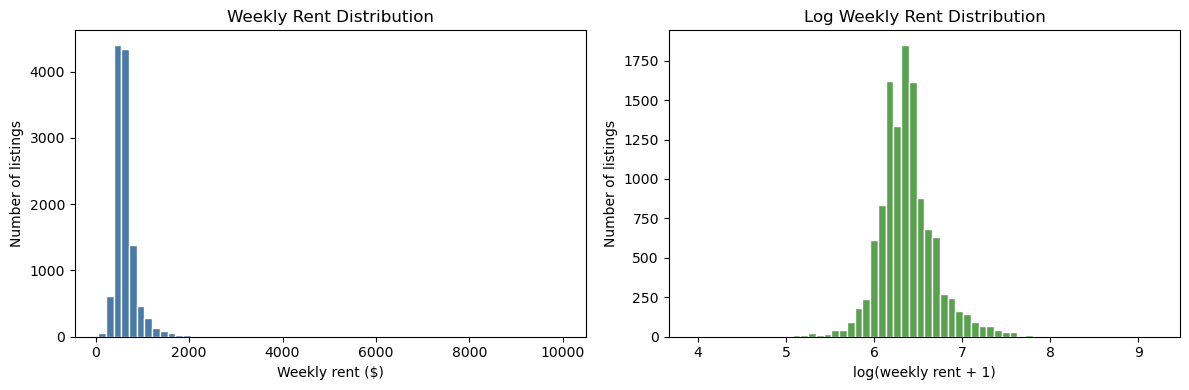

count   11,943.0000
mean       626.7788
std        288.5864
min         50.0000
25%        490.0000
50%        560.0000
75%        685.0000
90%        860.0000
95%      1,100.0000
99%      1,700.0000
max     10,000.0000
Name: weekly_rent, dtype: float64
Skewness: 7.024637374501679


In [77]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(model_df["weekly_rent"], bins=60, color="#4a7ba7", edgecolor="white")
axes[0].set_title("Weekly Rent Distribution")
axes[0].set_xlabel("Weekly rent ($)")
axes[0].set_ylabel("Number of listings")

axes[1].hist(np.log1p(model_df["weekly_rent"]), bins=60, color="#59a14f", edgecolor="white")
axes[1].set_title("Log Weekly Rent Distribution")
axes[1].set_xlabel("log(weekly rent + 1)")
axes[1].set_ylabel("Number of listings")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "weekly_rent_raw_vs_log_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

rent_summary = model_df["weekly_rent"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print(rent_summary)
print("Skewness:", model_df["weekly_rent"].skew())

## Feature Selection

The feature set includes internal property attributes, spatial accessibility features, nearby amenity counts, and SA2-level external features. The estimated route distance to the nearest station is retained instead of the straight-line station distance because it better represents practical accessibility and avoids duplicating near-identical predictors.

In [78]:
numeric_features = [
    # Internal property features
    "bedrooms",
    "bathrooms",
    "carspaces",

    # Spatial accessibility features
    "route_km_to_cbd",
    "est_route_km_to_nearest_station",
    "straight_km_to_nearest_school",
    "straight_km_to_nearest_park",
    "straight_km_to_nearest_mall",

    # Nearby amenity counts
    "n_stations_within_1km",
    "n_schools_within_1km",
    "n_parks_within_500m",

    # SA2 external features
    "income_median",
    "population_growth_5y",
    "population_density_2026",
]

categorical_features = [
    "primary_type",
    "suburb",
]

numeric_features = [c for c in numeric_features if c in model_df.columns]
categorical_features = [c for c in categorical_features if c in model_df.columns]
features = numeric_features + categorical_features

X = model_df[features].copy()
y = np.log1p(model_df["weekly_rent"])

missing_summary = (
    X.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)
missing_summary["missing_percentage"] = missing_summary["missing_count"] / len(X) * 100

print("X shape:", X.shape)
print("y shape:", y.shape)
missing_summary

X shape: (11943, 16)
y shape: (11943,)


,missing_count,missing_percentage
bedrooms,0,0.0000
bathrooms,0,0.0000
carspaces,0,0.0000
route_km_to_cbd,0,0.0000
est_route_km_to_nearest_station,0,0.0000
straight_km_to_nearest_school,0,0.0000
straight_km_to_nearest_park,0,0.0000
straight_km_to_nearest_mall,0,0.0000
n_stations_within_1km,0,0.0000
n_schools_within_1km,0,0.0000


## Train, Validation, and Test Split

A random train-validation-test split is used for the main model tuning workflow. The validation set is used for parameter tuning and model comparison, while the test set is held out for final evaluation only. A time-based split is also created later as a sensitivity check.

In [79]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (7165, 16)
Validation: (2389, 16)
Test: (2389, 16)


In [80]:
def build_preprocessor():
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ],
        remainder="drop",
    )

def rmse_score(actual, predicted):
    return mean_squared_error(actual, predicted) ** 0.5

def evaluate_predictions(y_true_log, y_pred_log):
    y_true_rent = np.expm1(y_true_log)
    y_pred_rent = np.expm1(y_pred_log)
    y_pred_rent = np.clip(y_pred_rent, 0, None)
    return {
        "MAE": mean_absolute_error(y_true_rent, y_pred_rent),
        "RMSE": rmse_score(y_true_rent, y_pred_rent),
        "R2": r2_score(y_true_rent, y_pred_rent),
    }

def make_pipeline(model):
    return Pipeline(steps=[
        ("preprocessor", build_preprocessor()),
        ("model", model),
    ])

def build_model(model_name, params):
    if model_name == "Ridge Regression":
        return Ridge(**params)
    if model_name == "Random Forest":
        return RandomForestRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1)
    if model_name == "Gradient Boosting":
        return GradientBoostingRegressor(**params, random_state=RANDOM_STATE)
    raise ValueError(f"Unknown model: {model_name}")

## Validation-Based Model Tuning

The candidate models are tuned using the validation set. Ridge Regression provides a linear baseline, while Random Forest and Gradient Boosting are tree-based models that can capture non-linear relationships and interactions between property, location, and SA2-level features.

In [81]:
model_grids = {
    "Ridge Regression": {
        "alpha": [0.1, 1.0, 10.0],
    },
    "Random Forest": {
        "n_estimators": [200, 300, 500],
        "max_depth": [None, 16, 24],
        "min_samples_leaf": [1, 3, 5],
    },
    "Gradient Boosting": {
        "n_estimators": [300, 400, 500],
        "learning_rate": [0.10, 0.15, 0.20, 0.25],
        "max_depth": [3, 4, 5],
        "min_samples_leaf": [1, 3],
    },
}

validation_rows = []

for model_name, grid in model_grids.items():
    print(f"Tuning {model_name}...")
    for params in ParameterGrid(grid):
        model = build_model(model_name, params)
        pipe = make_pipeline(model)
        pipe.fit(X_train, y_train)
        y_val_pred_log = pipe.predict(X_val)
        metrics = evaluate_predictions(y_val, y_val_pred_log)
        validation_rows.append({
            "model": model_name,
            "params": params,
            **metrics,
        })

validation_results = pd.DataFrame(validation_rows).sort_values("RMSE").reset_index(drop=True)
validation_results.to_csv(OUTPUT_DIR / "rental_model_validation_results.csv", index=False)
validation_results.head(15)

Tuning Ridge Regression...
Tuning Random Forest...
Tuning Gradient Boosting...


,model,params,MAE,RMSE,R2
0,Gradient Boosting,"{'learning_rate': 0.2, 'max_depth': 4, 'min_sa...",74.5065,143.6178,0.6611
1,Gradient Boosting,"{'learning_rate': 0.2, 'max_depth': 4, 'min_sa...",74.5261,144.1854,0.6584
2,Gradient Boosting,"{'learning_rate': 0.15, 'max_depth': 4, 'min_s...",74.1882,144.6194,0.6563
3,Gradient Boosting,"{'learning_rate': 0.15, 'max_depth': 5, 'min_s...",73.1826,144.6304,0.6563
4,Gradient Boosting,"{'learning_rate': 0.15, 'max_depth': 5, 'min_s...",73.1555,144.8360,0.6553
5,Gradient Boosting,"{'learning_rate': 0.2, 'max_depth': 4, 'min_sa...",74.8671,145.0859,0.6541
6,Gradient Boosting,"{'learning_rate': 0.15, 'max_depth': 4, 'min_s...",74.4982,145.1907,0.6536
7,Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 5, 'min_sa...",73.2480,145.3001,0.6531
8,Gradient Boosting,"{'learning_rate': 0.2, 'max_depth': 3, 'min_sa...",74.2998,145.3430,0.6529
9,Gradient Boosting,"{'learning_rate': 0.15, 'max_depth': 5, 'min_s...",73.6683,145.5883,0.6517


## Final Test Evaluation

After selecting the best configuration from the validation set, the final model is refit using the combined training and validation data. The held-out test set is then used once for final evaluation.

In [82]:
best_model_name = validation_results.loc[0, "model"]
best_params = validation_results.loc[0, "params"]

print("Best validation model:", best_model_name)
print("Best parameters:", best_params)

X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

final_model = build_model(best_model_name, best_params)
final_pipe = make_pipeline(final_model)
final_pipe.fit(X_train_val, y_train_val)

y_test_pred_log = final_pipe.predict(X_test)
final_test_metrics = evaluate_predictions(y_test, y_test_pred_log)
final_test_results = pd.DataFrame([
    {"model": best_model_name, "params": best_params, **final_test_metrics}
])
final_test_results.to_csv(OUTPUT_DIR / "rental_model_final_test_results.csv", index=False)
final_test_results

Best validation model: Gradient Boosting
Best parameters: {'learning_rate': 0.2, 'max_depth': 4, 'min_samples_leaf': 3, 'n_estimators': 500}


,model,params,MAE,RMSE,R2
0,Gradient Boosting,"{'learning_rate': 0.2, 'max_depth': 4, 'min_sa...",74.8240,155.4193,0.6798


## Random Split vs Time-Based Split

The random split gives a stable mix of suburbs and property types in each subset. A time-based split is also checked because it better resembles predicting future listings from earlier listings. This is a sensitivity check rather than the only final evaluation strategy.

In [83]:
date_available = model_df["date_listed_dt"].notna()

if date_available.all():
    ordered_index = model_df.sort_values("date_listed_dt").index
    n = len(ordered_index)
    train_end = int(n * 0.60)
    val_end = int(n * 0.80)

    train_idx = ordered_index[:train_end]
    val_idx = ordered_index[train_end:val_end]
    test_idx = ordered_index[val_end:]

    X_train_time, y_train_time = X.loc[train_idx], y.loc[train_idx]
    X_val_time, y_val_time = X.loc[val_idx], y.loc[val_idx]
    X_test_time, y_test_time = X.loc[test_idx], y.loc[test_idx]

    time_pipe = make_pipeline(build_model(best_model_name, best_params))
    time_pipe.fit(X_train_time, y_train_time)

    y_val_time_pred_log = time_pipe.predict(X_val_time)
    y_test_time_pred_log = time_pipe.predict(X_test_time)

    split_comparison = pd.DataFrame([
        {"split": "random_validation", **validation_results.loc[0, ["MAE", "RMSE", "R2"]].to_dict()},
        {"split": "random_test", **final_test_metrics},
        {"split": "time_validation", **evaluate_predictions(y_val_time, y_val_time_pred_log)},
        {"split": "time_test", **evaluate_predictions(y_test_time, y_test_time_pred_log)},
    ])
else:
    split_comparison = pd.DataFrame([{
        "split": "time_split_not_available",
        "note": "date_listed contains missing or invalid dates",
    }])

split_comparison.to_csv(OUTPUT_DIR / "rental_model_split_comparison.csv", index=False)
split_comparison

,split,MAE,RMSE,R2
0,random_validation,74.5065,143.6178,0.6611
1,random_test,74.8240,155.4193,0.6798
2,time_validation,75.0981,143.5053,0.6509
3,time_test,72.9495,129.0186,0.6855


## Influence Diagnostics Using Cook's Distance

Cook's distance is a diagnostic for linear models, so it is used here as an influence screening tool rather than as a direct tree-model diagnostic. The purpose is to identify listings that are highly influential in a linear approximation, then compare the selected model's validation performance before and after excluding those observations from training.

In [84]:
# Fit the preprocessor on the random training set and compute Cook's distance
# using a linear regression approximation.
cook_preprocessor = build_preprocessor()
X_train_encoded = cook_preprocessor.fit_transform(X_train)
y_train_array = y_train.to_numpy()

linear_model = LinearRegression()
linear_model.fit(X_train_encoded, y_train_array)
y_train_hat = linear_model.predict(X_train_encoded)
residuals = y_train_array - y_train_hat

n_obs = X_train_encoded.shape[0]
X_design = np.column_stack([np.ones(n_obs), X_train_encoded])
n_params = X_design.shape[1]

xtx_inv = np.linalg.pinv(X_design.T @ X_design)
hat_diag = np.sum((X_design @ xtx_inv) * X_design, axis=1)
mse_linear = np.sum(residuals ** 2) / max(n_obs - n_params, 1)

cooks_distance = (residuals ** 2 / (n_params * mse_linear)) * (hat_diag / (1 - hat_diag) ** 2)
cooks_threshold = 4 / n_obs

cooks_df = pd.DataFrame({
    "listing_index": X_train.index,
    "cooks_distance": cooks_distance,
    "is_influential": cooks_distance > cooks_threshold,
}).set_index("listing_index")

print("Cook's distance threshold:", cooks_threshold)
print("Influential training observations:", int(cooks_df["is_influential"].sum()))
print("Training observations:", n_obs)

cooks_df.sort_values("cooks_distance", ascending=False).head(10)

Cook's distance threshold: 0.0005582693649685974
Influential training observations: 412
Training observations: 7165


/var/folders/yx/tqrjyttd2p30z19l0p3ckfyh0000gn/T/ipykernel_92984/858625007.py:20: RuntimeWarning: divide by zero encountered in divide
  cooks_distance = (residuals ** 2 / (n_params * mse_linear)) * (hat_diag / (1 - hat_diag) ** 2)


,cooks_distance,is_influential
listing_index,,
2229,inf,True
10299,inf,True
11064,inf,True
534,inf,True
10965,inf,True
10250,inf,True
2977,"98,449,100,111,134,544,451,600,384.0000",True
5675,"90,992,120,929,012,113,129,603,072.0000",True
10942,"82,908,881,091,453,295,894,986,752.0000",True


In [85]:
non_influential_train_idx = cooks_df.index[~cooks_df["is_influential"]]

influence_pipe = make_pipeline(build_model(best_model_name, best_params))
influence_pipe.fit(X_train.loc[non_influential_train_idx], y_train.loc[non_influential_train_idx])

y_val_pred_original_log = make_pipeline(build_model(best_model_name, best_params)).fit(X_train, y_train).predict(X_val)
y_val_pred_influence_log = influence_pipe.predict(X_val)

influence_comparison = pd.DataFrame([
    {"training_data": "all_training_rows", **evaluate_predictions(y_val, y_val_pred_original_log)},
    {"training_data": "excluding_influential_rows", **evaluate_predictions(y_val, y_val_pred_influence_log)},
])

influence_comparison.to_csv(OUTPUT_DIR / "rental_model_influence_comparison.csv", index=False)
influence_comparison

,training_data,MAE,RMSE,R2
0,all_training_rows,74.5065,143.6178,0.6611
1,excluding_influential_rows,71.8536,146.9353,0.6453


## Feature Importance

For tree-based final models, feature importance is used to interpret which property and external features contribute most to rental price prediction. If the selected final model is Ridge Regression, this section should be replaced with coefficient interpretation.

In [86]:
final_estimator = final_pipe.named_steps["model"]
feature_names = final_pipe.named_steps["preprocessor"].get_feature_names_out()

if hasattr(final_estimator, "feature_importances_"):
    importance_df = (
        pd.DataFrame({
            "feature": feature_names,
            "importance": final_estimator.feature_importances_,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
else:
    importance_df = (
        pd.DataFrame({
            "feature": feature_names,
            "coefficient": final_estimator.coef_,
            "abs_coefficient": np.abs(final_estimator.coef_),
        })
        .sort_values("abs_coefficient", ascending=False)
        .reset_index(drop=True)
    )

importance_df.to_csv(OUTPUT_DIR / "rental_model_feature_importance.csv", index=False)
importance_df.head(20)

,feature,importance
0,num__route_km_to_cbd,0.3162
1,num__bedrooms,0.2030
2,num__bathrooms,0.1873
3,num__income_median,0.0473
4,num__population_growth_5y,0.0341
5,num__population_density_2026,0.0308
6,num__carspaces,0.0204
7,num__est_route_km_to_nearest_station,0.0190
8,num__straight_km_to_nearest_mall,0.0185
9,num__straight_km_to_nearest_park,0.0182


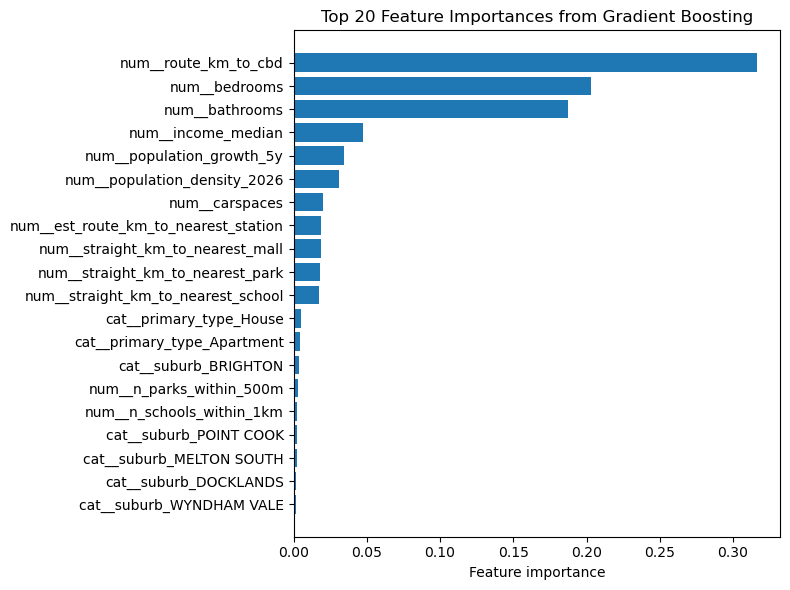

In [87]:
top_n = 20

if "importance" in importance_df.columns:
    plot_df = importance_df.head(top_n).sort_values("importance")
    x_col = "importance"
    x_label = "Feature importance"
    title = f"Top {top_n} Feature Importances from {best_model_name}"
else:
    plot_df = importance_df.head(top_n).sort_values("abs_coefficient")
    x_col = "abs_coefficient"
    x_label = "Absolute coefficient"
    title = f"Top {top_n} Coefficients from {best_model_name}"

plt.figure(figsize=(8, 6))
plt.barh(plot_df["feature"], plot_df[x_col])
plt.xlabel(x_label)
plt.title(title)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "rental_model_top20_feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()

## Final Prediction Plot

The final plot compares actual and predicted weekly rent on the original dollar scale. Points closer to the red diagonal line indicate better prediction accuracy.

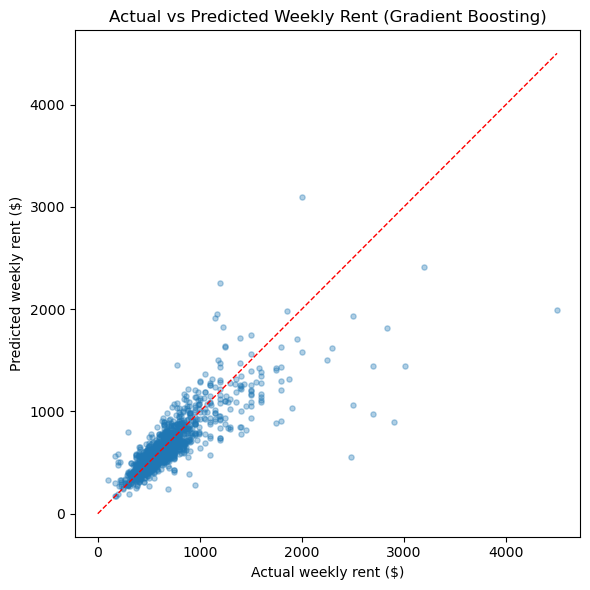

In [88]:
y_test_rent = np.expm1(y_test)
y_test_pred_rent = np.expm1(y_test_pred_log)
y_test_pred_rent = np.clip(y_test_pred_rent, 0, None)

plt.figure(figsize=(6, 6))
plt.scatter(y_test_rent, y_test_pred_rent, alpha=0.35, s=14)

max_rent = max(y_test_rent.max(), y_test_pred_rent.max())
plt.plot([0, max_rent], [0, max_rent], color="red", linestyle="--", linewidth=1)

plt.xlabel("Actual weekly rent ($)")
plt.ylabel("Predicted weekly rent ($)")
plt.title(f"Actual vs Predicted Weekly Rent ({best_model_name})")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "rental_model_actual_vs_predicted.png", dpi=200, bbox_inches="tight")
plt.show()